### Multimodal RAG (PDF With Images)

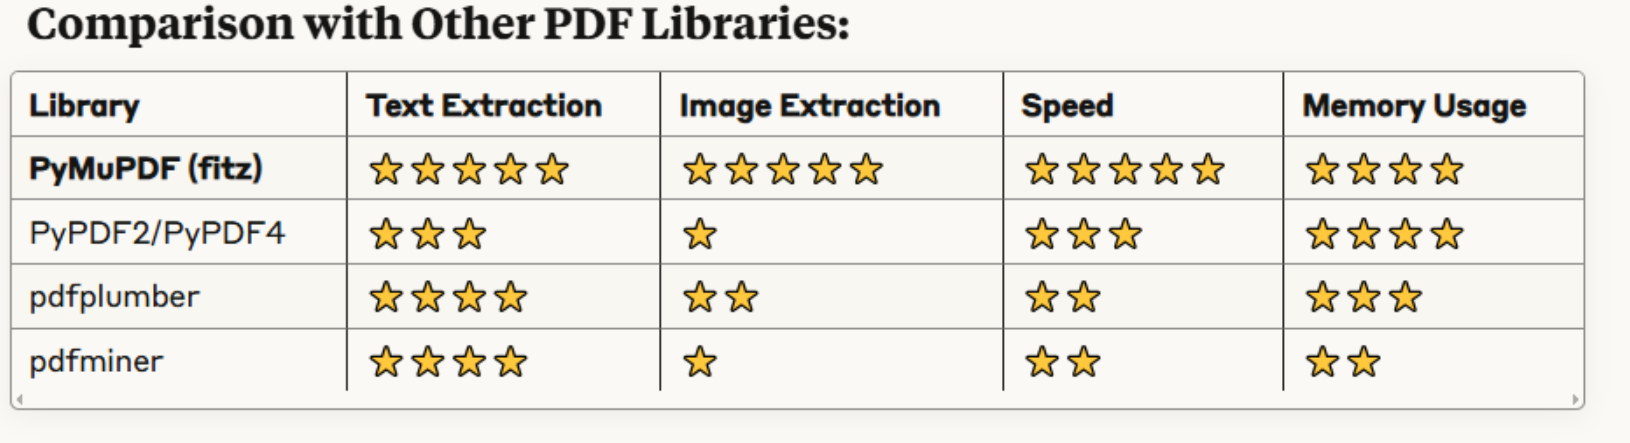

In [1]:
import fitz # PyMuPDF
from langchain_core.documents import Document
from transformers import CLIPProcessor, CLIPModel
from PIL import Image
import torch
import numpy as np
from langchain_openai import ChatOpenAI
from langchain_classic.prompts import PromptTemplate
from langchain_classic.schema.messages import HumanMessage
from sklearn.metrics.pairwise import cosine_similarity
import os
import base64
import io
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS

In [2]:
# CLip Model

import os
from dotenv import load_dotenv

load_dotenv()
api_key = os.getenv("OPENAI_API_KEY")
base_url = os.getenv("OPENAI_BASE_URL")

# initialize the Clip Model for unified embeddings
clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
clip_model.eval()

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


CLIPModel(
  (text_model): CLIPTextTransformer(
    (embeddings): CLIPTextEmbeddings(
      (token_embedding): Embedding(49408, 512)
      (position_embedding): Embedding(77, 512)
    )
    (encoder): CLIPEncoder(
      (layers): ModuleList(
        (0-11): 12 x CLIPEncoderLayer(
          (self_attn): CLIPAttention(
            (k_proj): Linear(in_features=512, out_features=512, bias=True)
            (v_proj): Linear(in_features=512, out_features=512, bias=True)
            (q_proj): Linear(in_features=512, out_features=512, bias=True)
            (out_proj): Linear(in_features=512, out_features=512, bias=True)
          )
          (layer_norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (mlp): CLIPMLP(
            (activation_fn): QuickGELUActivation()
            (fc1): Linear(in_features=512, out_features=2048, bias=True)
            (fc2): Linear(in_features=2048, out_features=512, bias=True)
          )
          (layer_norm2): LayerNorm((512,), eps=1e-05,

In [3]:
### Embedding functions
def embed_image(image_data):
    """Embed image using CLIP"""
    if isinstance(image_data, str):  # If path
        image = Image.open(image_data).convert("RGB")
    else:  # If PIL Image
        image = image_data
    
    inputs = clip_processor(images=image, return_tensors="pt")
    with torch.no_grad():
        # 直接使用视觉编码器
        vision_outputs = clip_model.vision_model(**inputs)
        # 获取pooled输出（已通过投影层）
        image_embeds = clip_model.visual_projection(vision_outputs[1])
        # Normalize embeddings to unit vector
        image_embeds = image_embeds / image_embeds.norm(dim=-1, keepdim=True)
        return image_embeds.squeeze().numpy()
    
def embed_text(text):
    """Embed text using CLIP."""
    inputs = clip_processor(
        text=text, 
        return_tensors="pt", 
        padding=True,
        truncation=True,
        max_length=77  # CLIP's max token length
    )
    with torch.no_grad():
        # 直接使用文本编码器
        text_outputs = clip_model.text_model(**inputs)
        # 获取pooled输出（已通过投影层）
        text_embeds = clip_model.text_projection(text_outputs[1])
        # Normalize embeddings
        text_embeds = text_embeds / text_embeds.norm(dim=-1, keepdim=True)
        return text_embeds.squeeze().numpy()

In [4]:
### 修复版本：重新运行提取逻辑，添加详细错误处理
# 先清空之前的数据
all_docs = []
all_embeddings = []
image_data_store = {}

pdf_path = "multimodal_sample.pdf"
doc = fitz.open(pdf_path)

print(f"开始处理 {pdf_path}")
print(f"总页数: {len(doc)}\n")

# Text splitter
splitter = RecursiveCharacterTextSplitter(
    chunk_size=500,
    chunk_overlap=100
)

for i, page in enumerate(doc):
    print(f"=== 处理第 {i} 页 ===")
    
    ## process text
    text = page.get_text()
    if text.strip():
        print(f"  文本提取: {len(text)} 个字符")
        ## create temporary document for splitting
        temp_doc = Document(page_content=text, metadata={"page": i, "type": "text"})
        text_chunks = splitter.split_documents([temp_doc])

        ## Embed each chunk using CLIP
        for chunk_idx, chunk in enumerate(text_chunks):
            try:
                embedding = embed_text(chunk.page_content)
                all_embeddings.append(embedding)
                all_docs.append(chunk)
                print(f"  ✓ 文本块 {chunk_idx}: 嵌入成功")
            except Exception as e:
                print(f"  ✗ 文本块 {chunk_idx} 出错: {e}")

    ## process image
    images = page.get_images(full=True)
    print(f"  找到 {len(images)} 张图片")
    
    for img_index, img in enumerate(images):
        print(f"    处理图片 {img_index}...")
        try:
            xref = img[0]
            base_image = doc.extract_image(xref)
            image_bytes = base_image['image']

            # Convert to PIL image
            pil_image = Image.open(io.BytesIO(image_bytes)).convert("RGB")
            print(f"      - PIL Image 大小: {pil_image.size}")

            # Create unique identifier
            image_id = f"page_{i}_image_{img_index}"

            # Store image base64 for later use with GPT-4V
            buffered = io.BytesIO()
            pil_image.save(buffered, format="PNG")
            image_base64 = base64.b64encode(buffered.getvalue()).decode()
            image_data_store[image_id] = image_base64
            print(f"      - Base64 保存: {len(image_base64)} 字符")

            # Embed image using CLIP
            embedding = embed_image(pil_image)
            all_embeddings.append(embedding)
            print(f"      - CLIP 嵌入成功: {embedding.shape}")

            # Create document for image
            image_doc = Document(
                page_content="",
                metadata={"page": i, "image_id": image_id, "type": "image"}
            )
            all_docs.append(image_doc)
            print(f"      ✓ 图片 {image_id} 已添加到 all_docs")

        except Exception as e:
            import traceback
            print(f"    ✗ 错误处理图片 {img_index}: {type(e).__name__}: {e}")
            traceback.print_exc()

doc.close()

print(f"\n=== 提取完成 ===")
print(f"总文档数: {len(all_docs)}")
print(f"文本文档: {sum(1 for d in all_docs if d.metadata.get('type') == 'text')}")
print(f"图片文档: {sum(1 for d in all_docs if d.metadata.get('type') == 'image')}")
print(f"总嵌入数: {len(all_embeddings)}")
print(f"image_data_store 大小: {len(image_data_store)}")


开始处理 multimodal_sample.pdf
总页数: 1

=== 处理第 0 页 ===
  文本提取: 365 个字符
  ✓ 文本块 0: 嵌入成功
  找到 1 张图片
    处理图片 0...
      - PIL Image 大小: (400, 300)
      - Base64 保存: 1476 字符
      - CLIP 嵌入成功: (512,)
      ✓ 图片 page_0_image_0 已添加到 all_docs

=== 提取完成 ===
总文档数: 2
文本文档: 1
图片文档: 1
总嵌入数: 2
image_data_store 大小: 1


In [5]:
all_docs

[Document(metadata={'page': 0, 'type': 'text'}, page_content='Annual Revenue Overview\nThis document summarizes the revenue trends across Q1, Q2, and Q3. As illustrated in the chart\nbelow, revenue grew steadily with the highest growth recorded in Q3.\nQ1 showed a moderate increase in revenue as new product lines were introduced. Q2 outperformed\nQ1 due to marketing campaigns. Q3 had exponential growth due to global expansion.'),
 Document(metadata={'page': 0, 'image_id': 'page_0_image_0', 'type': 'image'}, page_content='')]

In [6]:
embeddings_array = np.array(all_embeddings)
vector_store = FAISS.from_embeddings(
    text_embeddings=[(doc.page_content, emb) for doc, emb in zip(all_docs, all_embeddings)],
    embedding=None,
    metadatas=[doc.metadata for doc in all_docs]
)
vector_store

`embedding_function` is expected to be an Embeddings object, support for passing in a function will soon be removed.


In [7]:

llm = ChatOpenAI(
    model="gpt-4.1",
    temperature=0.4,
    api_key=api_key,
    base_url=base_url
)
llm

ChatOpenAI(profile={'max_input_tokens': 1047576, 'max_output_tokens': 32768, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'structured_output': True, 'image_url_inputs': True, 'pdf_inputs': True, 'pdf_tool_message': True, 'image_tool_message': True, 'tool_choice': True}, client=<openai.resources.chat.completions.completions.Completions object at 0x0000019755B23380>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x0000019754240050>, root_client=<openai.OpenAI object at 0x0000019755B20440>, root_async_client=<openai.AsyncOpenAI object at 0x0000019755B23CB0>, model_name='gpt-4.1', temperature=0.4, model_kwargs={}, openai_api_key=SecretStr('**********'), openai_api_base='https://yibuapi.com/v1')

In [8]:
def retrieve_multimodel(query, k = 5):
    """Unified retrieval using CLIP embeddings for both text and images"""
    # Embed query using CLIP
    query_embedding = embed_text(query)

    # Search in unified vector store
    results = vector_store.similarity_search_by_vector(
        embedding=query_embedding,
        k = k
    )
    return results

In [9]:
def create_multimodel_message(query, retrieved_docs):
    """Create a message with both text and images for CPT-4V"""
    content = []

    # Add the query
    content.append({
        "type": "text",
        "text": f"Question: {query}\n\nContent: \n"
    })

    # Separate text and image documents
    text_docs = [doc for doc in retrieved_docs if doc.metadata.get("type") == "text"]
    image_docs = [doc for doc in retrieved_docs if doc.metadata.get("type") == "image"]

    # Add text documents
    if text_docs:
        text_context = "\n\n".join([
            f"[Page {doc.metadata['page']}] : {doc.page_content}"
            for doc in text_docs
        ])
        content.append({
            "type": "text",
            "text": f"Text excerpts: \n{text_context} \n"
        })

    # Add image documents
    for doc in image_docs:
        image_id = doc.metadata.get("image_id")
        if image_id and image_id in image_data_store:
            content.append({
                "type": "text",
                "text": f"\n[Image from page {doc.metadata['page']}]:\n"
            })
            content.append({
                "type": "image_url",
                "image_url": {
                    "url": f"data:image/jpeg;base64,{image_data_store[image_id]}"
                }
            })

    # Add instruction
    content.append({
        "type": "text",
        "text": "\n\nPlease answer the question based on the provided text and images.."
    })

    return HumanMessage(content=content)

In [10]:
def multimodel_pdf_rag_pipeline(query):
    """Main pipeline for multimodal PDF RAG"""
    context_docs = retrieve_multimodel(query, k = 5)
    
    # Print retrieved context info
    print(f"\nRetrieved {len(context_docs)} documents:")
    for doc in context_docs:
        doc_type = doc.metadata.get("type", "unknown")
        page = doc.metadata.get("page", "?")
        if doc_type == "text":
            preview = doc.page_content[:500] + "..." if len(doc.page_content) > 500 else doc.page_content
            print(f"  - Text from page {page}: {preview}")
        else:
            print(f"  - Image from page {page}")
    print("\n")


    message = create_multimodel_message(query, context_docs)

    response = llm.invoke([message])

    return response.content

In [11]:
if __name__ == "__main__":
    # Example queries
    queries = [
        "What does the chart on page 1 show about revenue trends?",
        "Summarize the main findings from the document",
        "What visual elements are present in the document?"
    ]
    
    for query in queries:
        print(f"\nQuery: {query}")
        print("-" * 50)
        answer = multimodel_pdf_rag_pipeline(query)
        print(f"Answer: {answer}")
        print("=" * 70)


Query: What does the chart on page 1 show about revenue trends?
--------------------------------------------------

Retrieved 2 documents:
  - Text from page 0: Annual Revenue Overview
This document summarizes the revenue trends across Q1, Q2, and Q3. As illustrated in the chart
below, revenue grew steadily with the highest growth recorded in Q3.
Q1 showed a moderate increase in revenue as new product lines were introduced. Q2 outperformed
Q1 due to marketing campaigns. Q3 had exponential growth due to global expansion.
  - Image from page 0


Answer: The chart on page 1 shows a clear upward trend in revenue across the first three quarters (Q1, Q2, and Q3). Each bar represents a quarter, with Q1 (blue) being the lowest, Q2 (green) higher, and Q3 (red) the highest. This visual trend matches the text, which explains that revenue increased moderately in Q1, grew more in Q2 due to marketing efforts, and saw the highest, exponential growth in Q3 as a result of global expansion. Overall, th